In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import math

In [2]:
crpdata = pd.read_csv('BTC-USDT/okx.csv')

datex = [datetime.fromtimestamp(i/1000) for i in crpdata['timestamp']]
npdate = np.array(datex[1:])

In [3]:
#log return function

def logrf(crpdata):
    return np.array([math.log(crpdata['close'][i]/crpdata['close'][i-1]) for i in range(1, len(crpdata['close']))]) 

#logrf(crpdata)

In [4]:
#volatility Function 

def vlf(crpdata):
    return np.array((crpdata['high'][1:]-crpdata['low'][1:])/crpdata['close'][1:])

#vlf(crpdata)

In [5]:
#upper/lower wick ratio

def uwrf(d):
    rng = (d['high'] - d['low']).replace(0, np.nan)
    r = (d['high'] - np.maximum(d['open'], d['close'])) / rng
    return r.fillna(0).iloc[1:].to_numpy()

def lwrf(d):
    rng = (d['high'] - d['low']).replace(0, np.nan)
    r = (np.minimum(d['open'], d['close']) - d['low']) / rng
    return r.fillna(0).iloc[1:].to_numpy()
#uwrf(crpdata)
#lwrf(crpdata)

In [6]:
#Dist to high/low

def dthl(data, windowsize):
   rh = data['high'].rolling(window=windowsize).max()
   rl = data['low'].rolling(window=windowsize).min()

   dth = (rh - data['close']) / data['close']
   dtl = (data['close'] - rl) / data['close']

   return dth.fillna(0), dtl.fillna(0)

#print(dthl(data))

In [7]:
#volume Ratio

def vlr(crpdata, volume_window):
   vlsma = crpdata['volume'].rolling(window=volume_window).mean()
   vlr = crpdata['volume']/vlsma
   return np.array(vlr[1:].fillna(0))

#vlr(crpdata, 30)

In [8]:
#MA Diff

def cwf(crpdata, close_window):
   clma = crpdata['close'].rolling(window=close_window).mean()
   ma_diff = (crpdata['close'] - clma) / clma
   return np.array(ma_diff[1:].fillna(0))

#cwf(crpdata, 30)

In [9]:
#rsi function

def rsi(df, window):
    dlt = df.diff()
    gn = dlt.where(dlt > 0, 0.0)
    ls = -dlt.where(dlt < 0, 0.0)
    agn = gn.ewm(alpha=1 / window, adjust=False).mean()
    als = ls.ewm(alpha=1 / window, adjust=False).mean()
    rs = agn / als
    rsi = 100 - (100 / (1 + rs))
    return np.array(rsi.fillna(0) / 100.0)


#print(rsi(crpdata['close'][1:], 30))

In [10]:
def buildxw(datacrpDt, window_size, Future_period):
   bgh = len(datacrpDt)-Future_period-((len(datacrpDt)-Future_period)//window_size)*window_size
   #data_crop = [datacrpDt[bgh+(window_size*i):bgh+(window_size*(i+1))] for i in range((len(datacrpDt)-Future_period)//window_size)]
   data_crop = [datacrpDt[bgh+i:bgh+window_size+i] for i in range((len(datacrpDt)-Future_period))]

   return np.array(data_crop)

def buildyw(datacrpDt, window_size, Future_period):
   bgh = len(datacrpDt)-Future_period-((len(datacrpDt)-Future_period)//window_size)*window_size
   #fp_ndc = [datacrpDt[bgh+(window_size*(i+1)):bgh+(window_size*(i+1))+Future_period] for i in range((len(datacrpDt)-Future_period)//window_size)]
   fp_ndc = [datacrpDt[bgh+window_size+i:bgh+window_size+i+Future_period] for i in range((len(datacrpDt)-Future_period))]

   return np.array(fp_ndc)

In [11]:
def make_windows(X, y, W, F):
    xs, ys = [], []
    bgh = len(X)-F-((len(X)-F)//W)*W
    for i in range(bgh, len(X) - W - F + 1):
        xs.append(X[i:i+W])
        ys.append(y[i+W:i+W+F])
    return np.array(xs), np.array(ys)

In [12]:
tdst = pd.DataFrame()

formula_window = 10

tdst['logrf'] = logrf(crpdata)
tdst['vlf'] = vlf(crpdata)
tdst['uwrf'] = uwrf(crpdata)
tdst['lwrf'] = lwrf(crpdata)
tdst['vlr'] = vlr(crpdata, formula_window)
tdst['cwf'] = cwf(crpdata, formula_window)
tdst['rsi'] = rsi(crpdata['close'][1:], formula_window)
dth, dtl = dthl(crpdata, formula_window)
tdst['dth'] = dth.iloc[1:].to_numpy()
tdst['dtl'] = dtl.iloc[1:].to_numpy()


In [13]:
import torch

window_size = 30
Future_period = 7
num_formula = 9

split = int(len(tdst) * 0.8)              

mu = tdst.iloc[:split].mean()
sd = tdst.iloc[:split].std().replace(0, 1)
X = ((tdst - mu) / sd).to_numpy()          
y = tdst['logrf'].to_numpy()              

xs, ys = make_windows(X, y, window_size, Future_period)
ys = ys.sum(axis=1, keepdims=True)        

n_trn = split - window_size - Future_period + 1
x_trn, y_trn = xs[:n_trn], ys[:n_trn]
x_tst, y_tst = xs[split:],  ys[split:]

x_trn = torch.tensor(x_trn, dtype=torch.float32).permute(0, 2, 1)
x_tst = torch.tensor(x_tst, dtype=torch.float32).permute(0, 2, 1)
y_trn = torch.tensor(y_trn, dtype=torch.float32)
y_tst = torch.tensor(y_tst, dtype=torch.float32)

In [14]:
import torch
import torch.nn as nn
from torch.nn import Module, MSELoss
from torch.utils.data import Dataset, DataLoader
from torch.optim import adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
class Datast(Dataset):
    def __init__(self,xprd, yprd):
        self.x = xprd
        self.y = yprd
    def __len__(self):
        return len(self.x)
    def __getitem__(self, index):
        return self.x[index], self.y[index]

In [16]:
class temporalblk(Module):
    def __init__(self, inputch, outputch, kernel_size, dillation):
        super(temporalblk, self).__init__()
        self.paddingCl = (kernel_size - 1) * dillation
        self.cv1 = nn.Conv1d(inputch, outputch, kernel_size, padding=self.paddingCl, dilation=dillation)
        self.rl1 = nn.ReLU()
        self.dp = nn.Dropout(0.2)
        self.cv2 = nn.Conv1d(inputch, outputch, kernel_size=1)
        self.rl2 = nn.GELU()
    def forward(self, x):
        out = self.cv1(x)
        if self.paddingCl != 0:
            out = out[:, :, :-self.paddingCl]
        out = self.dp(self.rl1(out))
        xrsp = self.cv2(x)
        return self.rl2(out + xrsp)


In [17]:
class tcnModel(Module):
    def __init__(self, input_num, output_channels, kernel_size, output_num):
        super(tcnModel, self).__init__()
        self.layers = []
        for ch in range(len(output_channels)):
            input_ch = input_num if ch == 0 else output_channels[ch-1]
            dilation_n = 2 ** ch
            self.layers.append(temporalblk(input_ch, output_channels[ch], kernel_size, dillation=dilation_n))
        self.network = nn.Sequential(*self.layers)
        self.fc = nn.Linear(output_channels[-1], output_num)
    def forward(self, x):
        x = self.network(x)
        x = x[:, :, -1]
        x = self.fc(x)
        return x

            

In [18]:
model2 = tcnModel(num_formula, [16, 32, 16], 3, output_num=1)

In [19]:
#x_trn, x_tst, y_trn, y_tst = train_test_split(xprd2, yprd2, test_size=0.2, shuffle=False)

dataset = Datast(x_trn, y_trn)
datald = DataLoader(dataset, batch_size=32, shuffle=False)

In [20]:
from torch.nn import MSELoss
from torch.optim import Adam

In [21]:
msels = MSELoss()
optmz = Adam(model2.parameters(), lr=1e-3, weight_decay=1e-4)

In [22]:
epoch = 100

tstls = []
valls = []
accls = []
#best, best_state, patience, bad = float('inf')
for eph in range(epoch):
    model2.train()
    trloss = 0.0
    for datax, labely in datald:
        ypred = model2(datax)
        loss = msels(ypred, labely)
        optmz.zero_grad()
        loss.backward()
        optmz.step()
        trloss += loss.item()
    model2.eval()
    with torch.no_grad():
        yts = model2(x_tst)
        vals = msels(yts, y_tst)
    acc = ((yts > 0) == (y_tst > 0)).float().mean().item()
    print(f"epoch: {eph}, train loss: {trloss/len(datald)}, validation loss: {vals}, directional accuracy: {acc}")
    tstls.append(trloss/len(datald))
    valls.append(vals)
    accls.append(acc)
print("finished train.")

epoch: 0, train loss: 0.01594765825596239, validation loss: 0.004424711223691702, directional accuracy: 0.515625
epoch: 1, train loss: 0.009532274188573605, validation loss: 0.004015900194644928, directional accuracy: 0.529296875
epoch: 2, train loss: 0.008828801931148128, validation loss: 0.0038949698209762573, directional accuracy: 0.53125
epoch: 3, train loss: 0.008597771690360138, validation loss: 0.0038658329285681248, directional accuracy: 0.5234375
epoch: 4, train loss: 0.008314219822308847, validation loss: 0.0038188653998076916, directional accuracy: 0.533203125
epoch: 5, train loss: 0.008242561545089951, validation loss: 0.0038101335521787405, directional accuracy: 0.53515625
epoch: 6, train loss: 0.008130091419609796, validation loss: 0.0038194567896425724, directional accuracy: 0.541015625
epoch: 7, train loss: 0.008107674486070339, validation loss: 0.003806100459769368, directional accuracy: 0.53515625
epoch: 8, train loss: 0.007990658885267165, validation loss: 0.00380479

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


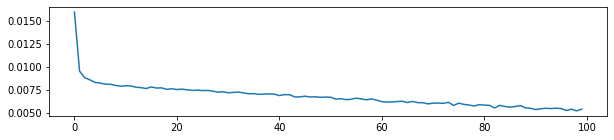

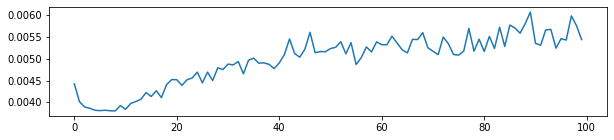

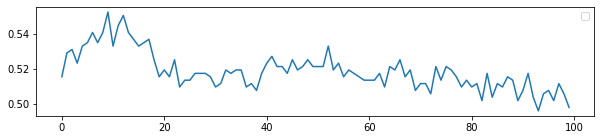

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))
plt.plot(np.arange(len(tstls)), np.array(tstls))

plt.figure(figsize=(10, 2))
plt.plot(np.arange(len(valls)), np.array(valls))

plt.figure(figsize=(10, 2))
plt.plot(np.arange(len(accls)), np.array(accls))

plt.legend()
plt.show()

In [24]:
from sklearn.linear_model import LogisticRegression

xf = x_trn.mean(dim=2).numpy()
xt = x_tst.mean(dim=2).numpy()

clf = LogisticRegression(max_iter=1000).fit(xf, (y_trn.numpy().ravel() > 0))
print(clf.score(xt, (y_tst.numpy().ravel() > 0)))

0.42578125
